In [1]:
import gpflow
import matplotlib.pyplot as plt 
import numpy as np  
import scipy.stats as ss
import tensorflow as tf 

import sys
sys.path.append("..")

from atmodel import AdaptiveTransferGPR, ConditionalMOGP
from atkernel import TransferKernel, TransferCoregion
from atlikelihood import TransferLikelihood

np.random.seed(42)

2025-10-23 10:26:35.512500: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-23 10:26:35.513939: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-23 10:26:35.542209: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-23 10:26:35.542900: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-23 10:26:36.161006: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

## Demonstration of transfer coregionalization
I am using "transfer" to indicate that the training procedure is conditional. 
The AT-GP or "adaptive transfer model/GP" is the one in Cao.
With "coregionalization GP"/ICM I mean the one found in GPFlow by default, which is the one described in Bonilla's paper.

The difference between the "adaptive transfer model" and the "transfer coregionalization model" is that in the adaptive transfer model, the weight matrix is $$B = \begin{bmatrix} 1 & \lambda \\ \lambda & 1 \end{bmatrix},$$
while in the ICM it's
$$W = \begin{bmatrix} a & b \\ c & d \end{bmatrix}, B = WW^{T} + \begin{bmatrix} \kappa & 1 \\ 1 & \kappa \end{bmatrix}$$
So $\kappa$ scales the variance in this, while $\lambda$ in the transfer kernel scales the covariance/captures the correlation between the source and target tasks. The nice thing about the ICM implementation is that everything is nice and PSD. 

In [2]:
def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot(m):
    plt.figure(figsize=(16, 4))
    Xtest = np.linspace(0, 100, 100)[:, None]
    (line,) = plt.plot(X1, Y1, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y1")
    (line,) = plt.plot(X2_full, Y2_full, "x", mew=2, alpha=0.5, color="orange")
    (line,) = plt.plot(X2, Y2, "x", mew=2, color="black")
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y2")

    plt.legend()


def plot_gpr(m):
    plt.figure(figsize=(16, 4))
    Xtest = np.linspace(0, 100, 100)[:, None]
    (line,) = plt.plot(X1, Y1, "x", mew=2, label="source data")
    mu, var = m.predict_f(Xtest)
    (line,) = plt.plot(X2_full, Y2_full, "x", mew=2, alpha=0.5, color="orange", label="all target data")
    (line,) = plt.plot(X2, Y2, "x", mew=2, color="black", label ="available target data")
    plot_gp(Xtest, mu, var, line.get_color(), "Y2")

    plt.legend()

PearsonRResult(statistic=array([0.59608093]), pvalue=array([6.03212712e-11]))


Text(0.5, 0, 'y')

<Figure size 800x400 with 0 Axes>

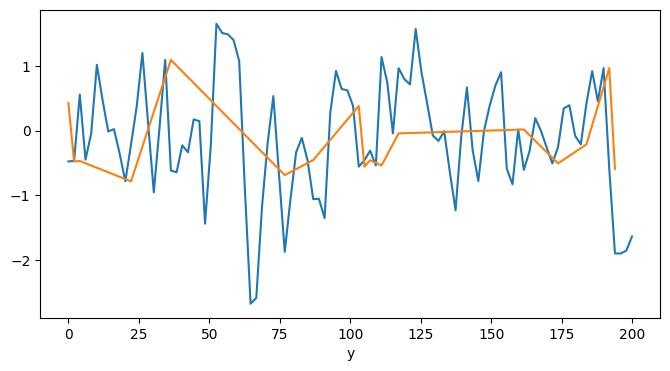

In [3]:
X1 = np.linspace(0, 200, 100)[:,None]  # Observed locations for first output
X2_full = np.linspace(0, 200, 100)[:,None]  # Observed locations for second output

Xall = np.linspace(0, 110, 110).reshape(-1, 1)
k = gpflow.kernels.RBF(active_dims=[0])
Yall  = np.random.multivariate_normal(np.zeros_like(Xall[:,0]), k(Xall))
Y1 = Yall[1:101][:,None]
Y2_full = Yall[0:100][:,None]
print(ss.pearsonr(Y1, Y2_full))
# Y1 = np.sin(6 * X1) + np.random.randn(*X1.shape) * 0.03
# Y2 = np.sin(6 * X2 + 0.7) + np.random.randn(*X2.shape) * 0.1

#ind = np.concatenate((np.arange(40), np.arange(70, 100)))
ind = np.sort(np.random.choice(np.arange(100), 20))
#ind = np.arange(0, 50, 1)
plt.figure(figsize=(8, 4))
X2 = X2_full[ind]
Y2 = Y2_full[ind]
plt.figure(figsize=(8, 4))
plt.plot(X1, Y1, mew=2)
plt.plot(X2, Y2,  mew=2)
plt.xlabel("X")
plt.xlabel("y")

In [4]:
ss.pearsonr(Y2_full, Y1)

PearsonRResult(statistic=array([0.59608093]), pvalue=array([6.03212712e-11]))

In [44]:
from gpflow.config import default_float
from gpflow import set_trainable
import time
from gpflow.ci_utils import reduce_in_tests


def build_conditional_model(data_source, data_target, mean_function, kernel=None):
    if kernel:
        kernel = kernel
    else:
        kernel = TransferCoregion(
                                    lmb=0.5, 
                                    kernel=gpflow.kernels.RBF(), 
                                    source_length=len(X1), use_lmb=False
                                    )
    #kernel = TransferKernel(0.5, gpflow.kernels.RBF(), len(data_source))
    model = AdaptiveTransferGPR(data_source=data_source, 
                            data_target=data_target, 
                            kernel=kernel, mean_function=mean_function
                            )
    #model = gpflow.models.GPR(data_source, kernel=gpflow.kernels.RBF(), mean_function=mean_function)
    set_trainable(model.kernel, False)
    model.likelihood.source.variance.assign(1e-2)
    model.likelihood.target.variance.assign(1e-2)
    set_trainable(model.likelihood, False)

    return model


def build_joint_model(data_source, data_target, mean_function):
    output_dim = 2  # Number of outputs
    rank = 1  # Rank of W

    # Base kernel
    k = gpflow.kernels.RBF(active_dims=[0])

    # Coregion kernel
    coreg = gpflow.kernels.Coregion(
        output_dim=output_dim, rank=rank, active_dims=[1]
    )

    kern = k * coreg
    #kern2 = TransferKernel(0.5, gpflow.kernels.RBF(), source_length=int(len(Y_augmented) - np.sum(Y_augmented[:,1])))

    # This likelihood switches between Gaussian noise with different variances for each f_i:
    lik = gpflow.likelihoods.SwitchedLikelihood(likelihood_list=[gpflow.likelihoods.Gaussian(), gpflow.likelihoods.Gaussian()])
    # now build the GP model as normal
    X_augmented = np.vstack((np.hstack((data_source[0], np.zeros_like(data_source[0]))), np.hstack((data_target[0], np.ones_like(data_target[0])))))
    Y_augmented = np.vstack((np.hstack((data_source[1], np.zeros_like(data_source[1]))), np.hstack((data_target[1], np.ones_like(data_target[1])))))

    model = gpflow.models.VGP((X_augmented, Y_augmented), kernel=kern, likelihood=lik, mean_function=mean_function)
    set_trainable(model.kernel, False)
    [l.variance.assign(1e-2) for l in lik.likelihoods]
    set_trainable(model.likelihood, False)
    return model


def build_mean_function(mogp=False):
    tf.keras.backend.set_floatx("float64")
    assert default_float() == np.float64

    inputs = tf.keras.layers.Input(shape=(1,))
    x = tf.keras.layers.Dense(64, activation="relu")(inputs)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    if not mogp:
        outputs = tf.keras.layers.Dense(1)(x)
    else:
        outputs=tf.keras.laysers.Dense(2)(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs)

def build_gp_mean_function(data_source, data_target):
    data = (np.concatenate((data_source[0], data_target[0])), np.concatenate((data_source[1], data_target[1])))
    model = gpflow.models.GPR(data, gpflow.kernels.RBF())
    return model 

def create_optimization_step(optimizer, model: gpflow.models.GPR):
    @tf.function
    def optimization_step():
        with tf.GradientTape(watch_accessed_variables=False) as tape:
            tape.watch(model.trainable_variables)
            objective = model.training_loss()
        grads = tape.gradient(objective, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        return objective

    return optimization_step


def run_adam(model, iterations):
    """
    Utility function running the Adam optimizer

    :param model: GPflow model
    :param interations: number of iterations
    """
    # Create an Adam Optimizer action
    logf = []
    adam = tf.optimizers.Adam(learning_rate=0.001)
    optimization_step = create_optimization_step(adam, model)
    for step in range(iterations):
        loss = optimization_step()
        if step % 10 == 0:
            # print("num variables", len(model.trainable_variables))
            logf.append(loss.numpy())
    return logf


def joint_train_loop(data_source, data_target):
    """
    Metalearning training loop. Trained for 100 epochs in original experiment.

    :param meta_tasks: list of metatasks.
    :param num_iter: number of iterations of tasks set
    :returns: a mean function object
    """
    # Initialize mean function
    num_iter = 1
    data = (np.concatenate((data_source[0], data_target[0])), np.concatenate((data_source[1], data_target[1])))
    mean_function_joint = build_mean_function()
    # Iterate for several passes over the tasks set
    for iteration in range(num_iter):
        ts = time.time()
        print("Currently in meta-iteration/epoch {}".format(iteration))
        joint_model = build_joint_model(data_source, data_target, mean_function=mean_function_joint)
        logf = run_adam(joint_model, reduce_in_tests(500))
        print(logf)
        print(">>>> iteration took {:.2f} s".format(time.time() - ts))
    return mean_function_joint
    
def conditional_train_loop(data_source, data_target):
    """
    Metalearning training loop. Trained for 100 epochs in original experiment.

    :param meta_tasks: list of metatasks.
    :param num_iter: number of iterations of tasks set
    :returns: a mean function object
    """
    # Initialize mean function
    num_iter = 40
    data = (np.concatenate((data_source[0], data_target[0])), np.concatenate((data_source[1], data_target[1])))
    mean_function_conditional = build_mean_function()
    # Iterate for several passes over the tasks set
    for iteration in range(num_iter):
        ts = time.time()
        print("Currently in meta-iteration/epoch {}".format(iteration))
        # Iterate over tasks
        conditional_model = build_conditional_model(data_source, data_target, mean_function=mean_function_conditional)
        logf = run_adam(conditional_model, reduce_in_tests(500))
        print(logf)
        print(">>>> iteration took {:.2f} s".format(time.time() - ts))
    return mean_function_conditional, conditional_model.kernel

In [45]:
mean_function_conditional, kernel = conditional_train_loop(data_source=(X1, Y1), data_target=(X2, Y2))
#mean_function_joint = joint_train_loop(data_source=(X1, Y1), data_target=(X2, Y2))
test_model_conditional = build_conditional_model(data_source=(X1, Y1), data_target=(X2, Y2), mean_function=mean_function_conditional)
test_model_conditional_nonadaptive = build_conditional_model(data_source=(X1, Y1), data_target=(X2, Y2), mean_function=gpflow.mean_functions.Zero())
test_model_joint = build_joint_model(data_source=(X1, Y1), data_target=(X2, Y2), mean_function=gpflow.mean_functions.Zero())

def mean_squared_error(y, y_pred):
    return np.mean((y - y_pred) ** 2)

gpflow.utilities.print_summary(test_model_conditional)
#gpflow.utilities.print_summary(test_model_joint)

optimizer = gpflow.optimizers.Scipy()
optimizer.minimize(test_model_joint.training_loss, test_model_joint.trainable_variables)
optimizer = gpflow.optimizers.Scipy()
optimizer.minimize(test_model_conditional_nonadaptive.training_loss, test_model_conditional_nonadaptive.trainable_variables)

Currently in meta-iteration/epoch 0


ValueError: in user code:

    File "/tmp/ipykernel_2581/221667464.py", line 83, in optimization_step  *
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
    File "/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/keras/optimizers/optimizer.py", line 1173, in apply_gradients  **
        grads_and_vars = self.aggregate_gradients(grads_and_vars)
    File "/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/keras/optimizers/optimizer.py", line 1139, in aggregate_gradients
        return optimizer_utils.all_reduce_sum_gradients(grads_and_vars)
    File "/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/keras/optimizers/utils.py", line 33, in all_reduce_sum_gradients
        filtered_grads_and_vars = filter_empty_gradients(grads_and_vars)
    File "/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/keras/optimizers/utils.py", line 77, in filter_empty_gradients
        raise ValueError(

    ValueError: No gradients pro

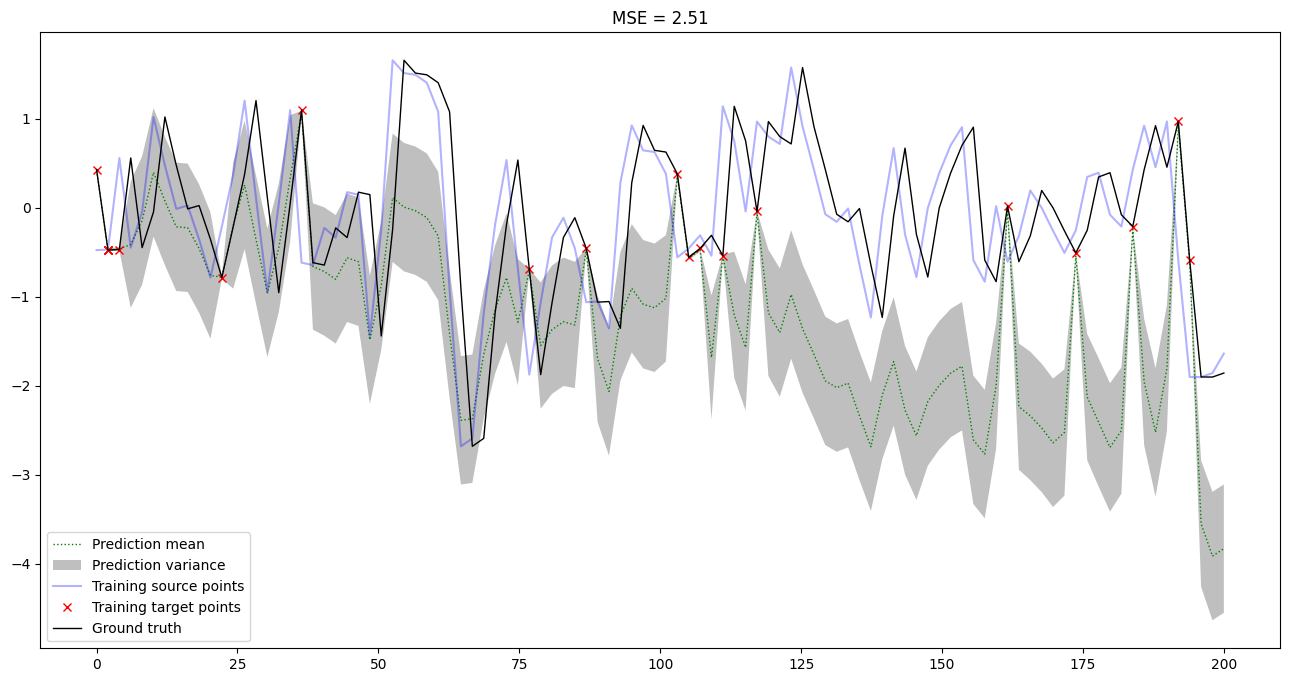

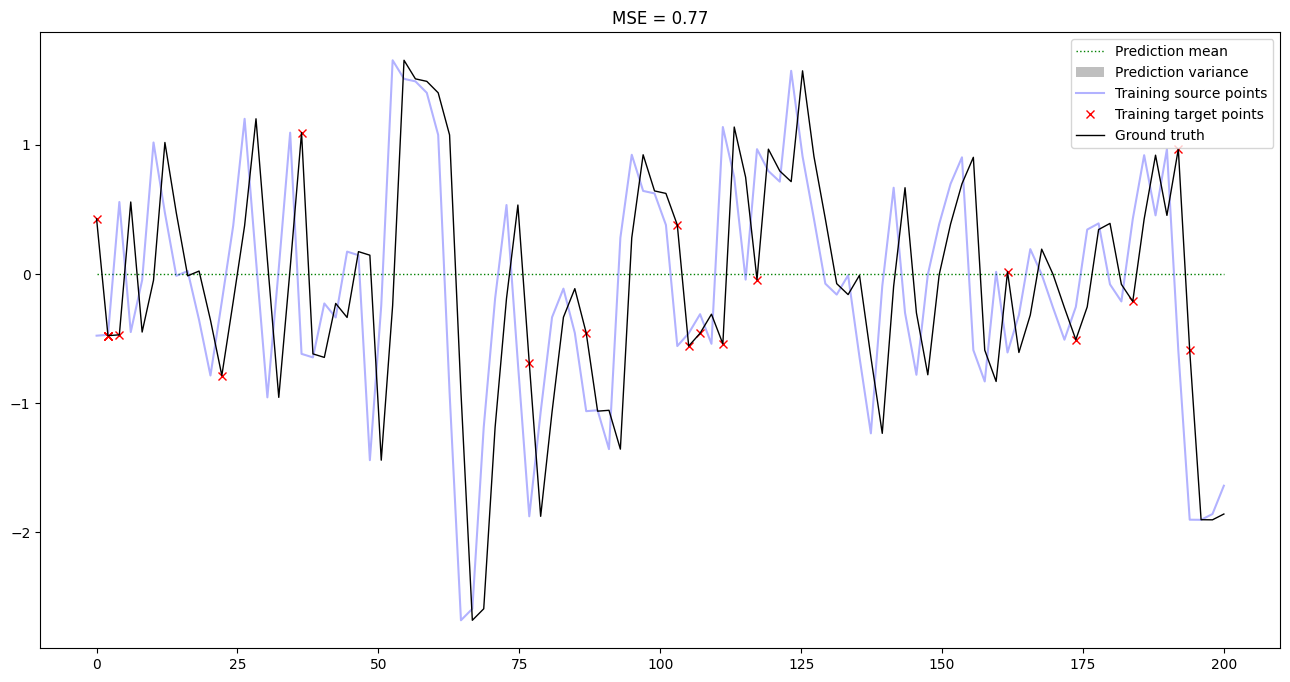

In [37]:
plt.figure(figsize=(16, 8))
pred_mean, pred_var = test_model_conditional.predict_f(X2_full)
plt.plot(X2_full, pred_mean, label="Prediction mean", color="green", linestyle=":", linewidth=1)
plt.fill_between(
    X2_full.squeeze(1),
    tf.squeeze(pred_mean - pred_var),
    tf.squeeze(pred_mean + pred_var),
    alpha=0.25,
    facecolor="black",
    label="Prediction variance",
)
plt.plot(X1, Y1, "b", alpha=0.3, label="Training source points")
plt.plot(X2, Y2, "rx", label="Training target points")
plt.plot(X2_full, Y2_full, "k", label="Ground truth", linewidth=1, markersize=1)
mse = mean_squared_error(Y2_full, pred_mean)
plt.title(f"MSE = {mse:.2f}")
plt.legend()
plt.show()


plt.figure(figsize=(16, 8))
pred_mean, pred_var = test_model_conditional_nonadaptive.predict_f(X2_full)
plt.plot(X2_full, pred_mean, label="Prediction mean", color="green", linestyle=":", linewidth=1)
plt.fill_between(
    X2_full.squeeze(1),
    tf.squeeze(pred_mean - pred_var),
    tf.squeeze(pred_mean + pred_var),
    alpha=0.25,
    facecolor="black",
    label="Prediction variance",
)
plt.plot(X1, Y1, "b", alpha=0.3, label="Training source points")
plt.plot(X2, Y2, "rx", label="Training target points")
plt.plot(X2_full, Y2_full, "k", label="Ground truth", linewidth=1, markersize=1)
mse = mean_squared_error(Y2_full, pred_mean)
plt.title(f"MSE = {mse:.2f}")
plt.legend()
plt.show()


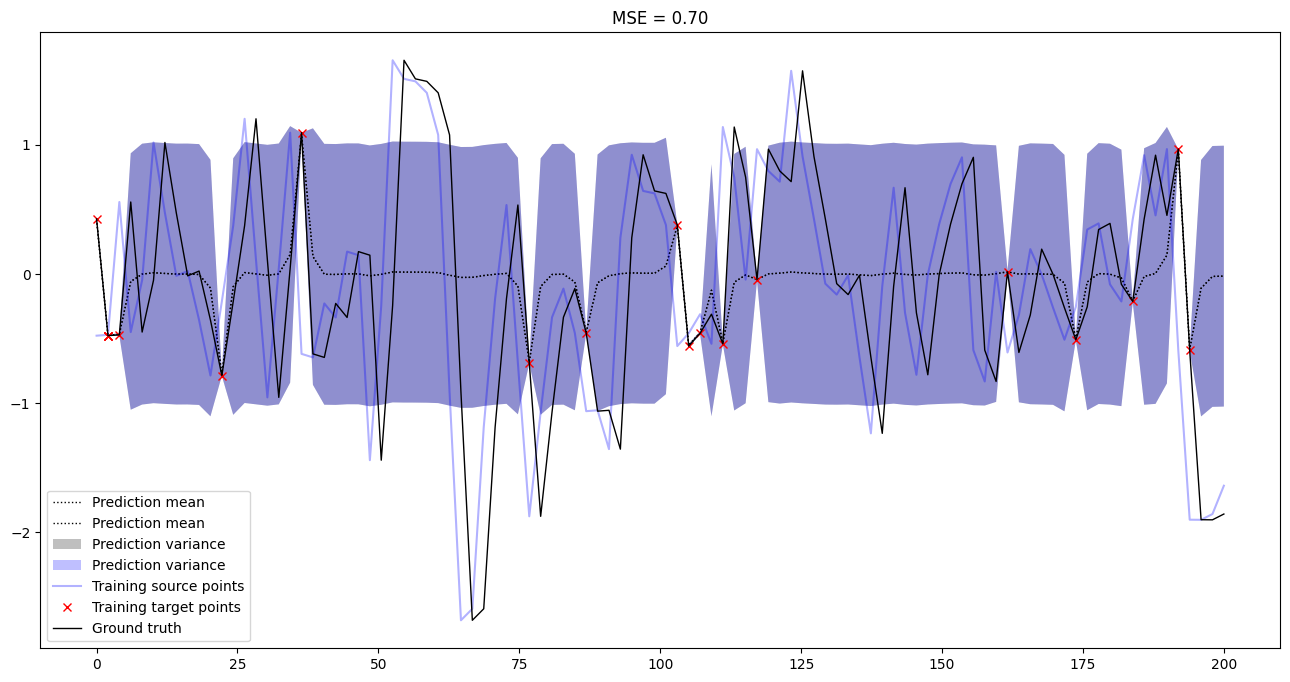

In [23]:
plt.figure(figsize=(16, 8))
pred_mean_S, pred_var_S = test_model_joint.predict_f(np.hstack((X1, np.ones_like(X1))))
pred_mean, pred_var = test_model_joint.predict_f(np.hstack((X2_full, np.ones_like(X2_full))))

plt.plot(X2_full, pred_mean, label="Prediction mean", color="black", linestyle=":", linewidth=1)
plt.plot(X1, pred_mean_S, label="Prediction mean", color="black", linestyle=":", linewidth=1)
plt.fill_between(
    X2_full.squeeze(1),
    tf.squeeze(pred_mean - pred_var),
    tf.squeeze(pred_mean + pred_var),
    alpha=0.25,
    facecolor="black",
    label="Prediction variance",
)
plt.fill_between(
    X1.squeeze(1),
    tf.squeeze(pred_mean_S - pred_var_S),
    tf.squeeze(pred_mean_S + pred_var_S),
    alpha=0.25,
    facecolor="blue",
    label="Prediction variance",
)
plt.plot(X1, Y1, "b", alpha=0.3, label="Training source points")
plt.plot(X2, Y2, "rx", label="Training target points")
plt.plot(X2_full, Y2_full, "k", label="Ground truth", linewidth=1, markersize=1)
mse = mean_squared_error(Y2_full, pred_mean)
plt.title(f"MSE = {mse:.2f}")
plt.legend()
plt.show()

### Quantifying performance

Thus far, we just evaluated things based on "do I like the look of this prediction", so time for some quantification:

In [ ]:
from sklearn.metrics import mean_squared_error
X1_filt = X1[[i for i in np.arange(100) if i not in ind]]
X2_filt = X2_full[[i for i in np.arange(100) if i not in ind]]
Y2_filt = Y2_full[[i for i in np.arange(100) if i not in ind]]
Y1_filt = Y1[[i for i in np.arange(100) if i not in ind]]

for i, model in enumerate([test_model_joint, test_model_conditional]):
    if i == 0:
        X2_filt_aug = np.hstack((X2_filt, np.ones_like(X2_filt)))
        X1_filt_aug = np.hstack((X1_filt, np.ones_like(X1_filt)))
        Y2_filt_aug = np.hstack((Y2_filt, np.ones_like(Y2_filt)))
        Y1_filt_aug = np.hstack((Y1_filt, np.ones_like(Y1_filt)))
        Yhat, Yvar = model.predict_f(X2_filt_aug)
        Y1hat, Y1var = model.predict_f(X1_filt_aug)
        Yhat = Yhat[:,0]
        print(f"{model=}", mean_squared_error(Yhat, Y2_filt_aug[:,0]))
        print(f"{model=}", mean_squared_error(Y1hat, Y1_filt_aug[:,0]))
    else:
        Yhat, Yvar = model.predict_f(X2_filt)
        Y1hat, Yvar = model.predict_f(X1_filt)
        print(f"{model=}", mean_squared_error(Yhat, Y2_filt[:,0]))
        print(f"{model=}", mean_squared_error(Y1hat, Y1_filt_aug[:,0]))

model=<gpflow.models.vgp.VGP object at 0x7ff2006b8810> 0.6671784835885513
model=<gpflow.models.vgp.VGP object at 0x7ff2006b8810> 0.6684636875311061
model=<atmodel.AdaptiveTransferGPR object at 0x7ff1bc298650> 0.5863156731079889
model=<atmodel.AdaptiveTransferGPR object at 0x7ff1bc298650> 0.284190118153243


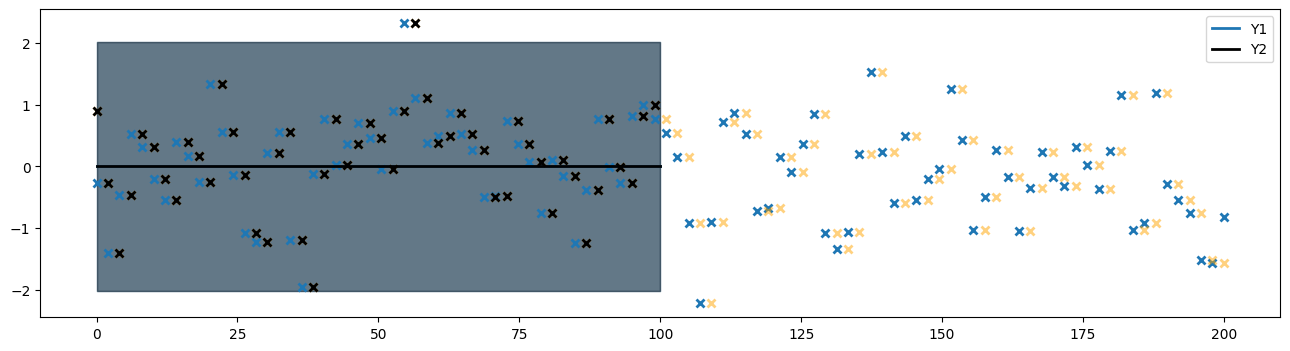

In [ ]:

def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot(m):
    plt.figure(figsize=(16, 4))
    Xtest = np.linspace(0, 100, 100)[:, None]
    (line,) = plt.plot(X1, Y1, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y1")
    (line,) = plt.plot(X2_full, Y2_full, "x", mew=2, alpha=0.5, color="orange")
    (line,) = plt.plot(X2, Y2, "x", mew=2, color="black")
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y2")

    plt.legend()

plot(test_model_joint)